In [2]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [3]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [4]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
from datasets import load_dataset
go_emotions = load_dataset("go_emotions")
print(go_emotions)

print(go_emotions['train'].features)
classes = go_emotions['train'].features['labels'].feature.names
print(f'\nClasses: {classes}')
len(classes)

train_data = pd.DataFrame(go_emotions['train'])
print(train_data)
counts = train_data['labels'].value_counts()
print(counts)
print(train_data['labels'])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', '

In [14]:
#EKMAN MAPPING
import json

with open('ekman_mapping.json') as f:
    ekman_mapping = json.load(f)

ekman_mapping['neutral'] = ["neutral"]

ekman_classes = list(ekman_mapping.keys())

ekman2id = {e: i for i, e in enumerate(ekman_classes)}

ekman_num = {
    0: "anger", 1: "anger", 2: "anger",  # anger, annoyance, disapproval
    3: "disgust",                         # disgust
    4: "fear", 5: "fear",                 # fear, nervousness
    6: "joy", 7: "joy", 8: "joy", 9: "joy", 10: "joy", 11: "joy", 12: "joy", 13: "joy", 14: "joy", 15: "joy", 16: "joy", 17: "joy",  # joy etc.
    18: "sadness", 19: "sadness", 20: "sadness", 21: "sadness", 22: "sadness",  # sadness etc.
    23: "surprise", 24: "surprise", 25: "surprise", 26: "surprise", # surprise etc.
    27: "neutral"  # neutral
}

print(ekman_mapping)
print(ekman_classes)
print(ekman2id)

def map_to_ekman(example):
    ekman_labels = set()

    for label in example["labels"]:
        ekman_category = ekman_num[label]
        ekman_labels.add(ekman_category)
        
    multi_hot = [0] * len(ekman_classes)
    for e in ekman_labels:
        multi_hot[ekman2id[e]] = 1

    example["labels"] = multi_hot
    return example
         
reduced_emotions = go_emotions.map(map_to_ekman)


train_data = pd.DataFrame(reduced_emotions['train'])
print(train_data)
counts = train_data['labels'].value_counts()
print(counts)

{'anger': ['anger', 'annoyance', 'disapproval'], 'disgust': ['disgust'], 'fear': ['fear', 'nervousness'], 'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'pride', 'admiration', 'desire', 'caring'], 'sadness': ['sadness', 'disappointment', 'embarrassment', 'grief', 'remorse'], 'surprise': ['surprise', 'realization', 'confusion', 'curiosity'], 'neutral': ['neutral']}
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']
{'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5, 'neutral': 6}
                                                    text  \
0      My favourite food is anything I didn't have to...   
1      Now if he does off himself, everyone will thin...   
2                         WHY THE FUCK IS BAYLESS ISOING   
3                            To make her feel threatened   
4                                 Dirty Southern Wankers   
...                                                  ...   
43

In [15]:
print(reduced_emotions['train'][0:8])

{'text': ["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers', "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.", 'Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝', 'We need more boards and to create a bit more space for [NAME]. Then we’ll be good.'], 'labels': [[0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0]], 'id': ['eebbqej', 'ed00q6i', 'eezlygj', 'ed7ypvh', 'ed0bdzj', 'edvnz26', 'ee3b6wu', 'ef4qmod']}


In [16]:
from transformers import AutoTokenizer, DataCollatorWithPadding

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_process_labels(examples):
    # Tokenize the text
    tokenized = tokenizer(examples["text"], 
                                 padding="max_length", 
                                 truncation=True)

    # Process labels for multi-label classification (one-hot encoding)
    labels_batch = []
    for labels_list in examples["labels"]:
        one_hot_labels = np.zeros(len(classes), dtype=float)
        for label_idx in labels_list:
            one_hot_labels[label_idx] = 1.0
        labels_batch.append(one_hot_labels.tolist()) # Convert to list for dataset

    tokenized["labels"] = labels_batch
    return tokenized

tokenized_go_emotions = go_emotions.map(tokenize_and_process_labels, batched=True, remove_columns = ['text'])
print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

class CustomDataCollator:
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).to(torch.float32)  # important!
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()

                                                  labels       id  \
0      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eebbqej   
1      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  ed00q6i   
2      [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eezlygj   
3      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...  ed7ypvh   
4      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  ed0bdzj   
...                                                  ...      ...   
43405  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  edsb738   
43406  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...  ee7fdou   
43407  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  efgbhks   
43408  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...  ed1naf8   
43409  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eecwmbq   

                                               input_ids  \
0      [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1      [101, 2085, 2065, 2002, 2515, 2125, 2370, 10

In [17]:
#EKMAN CLASSES VERS.

from transformers import AutoTokenizer, DataCollatorWithPadding

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_labelling(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation = True,
        padding = "max_length",
        max_length = 128)
    return tokenized

tokenized_go_emotions = reduced_emotions.map(tokenize_labelling, 
                                        batched = True, 
                                        remove_columns = ["text"])

print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

class CustomDataCollator:
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).to(torch.float32)  # important!
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()

#dynamically pads each batch to longest sequence in batch rather than padding every sequence - saves compute, memory
#mlm=False to avoid randomly masking tokens

                      labels       id  \
0      [0, 0, 0, 0, 0, 0, 1]  eebbqej   
1      [0, 0, 0, 0, 0, 0, 1]  ed00q6i   
2      [1, 0, 0, 0, 0, 0, 0]  eezlygj   
3      [0, 0, 0, 1, 0, 0, 0]  ed7ypvh   
4      [0, 1, 0, 0, 0, 0, 0]  ed0bdzj   
...                      ...      ...   
43405  [0, 0, 0, 0, 1, 0, 0]  edsb738   
43406  [0, 0, 0, 1, 0, 0, 0]  ee7fdou   
43407  [0, 1, 0, 0, 0, 0, 0]  efgbhks   
43408  [0, 0, 0, 1, 0, 0, 0]  ed1naf8   
43409  [0, 0, 0, 1, 0, 0, 0]  eecwmbq   

                                               input_ids  \
0      [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1      [101, 2085, 2065, 2002, 2515, 2125, 2370, 1010...   
2      [101, 2339, 1996, 6616, 2003, 3016, 3238, 1116...   
3      [101, 2000, 2191, 2014, 2514, 5561, 102, 0, 0,...   
4      [101, 6530, 2670, 14071, 11451, 102, 0, 0, 0, ...   
...                                                  ...   
43405  [101, 2794, 2017, 6775, 2092, 1045, 1521, 2310...   
43406  [101, 2467, 2245, 20

In [10]:
#Weights adjusted
y_train = np.array(tokenized_go_emotions["train"]["labels"])
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = neg_counts/pos_counts
pos_weight = torch.tensor(pos_weight, dtype = torch.float)
print(pos_weight)

tensor([ 4.4804, 16.5749,  9.9594,  2.2568,  7.7839, 13.3837,  2.0530])


In [ ]:
#Weights adjusted
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

class WeightedTrainer(Trainer): #creates new class inheriting from Trainer
    def __init__(self, *args, pos_weight=None, **kwargs): #*args passes any number of positional arguments, **kwargs pass any number of keyword (named) arguments. 
        super().__init__(*args, **kwargs) #calls original Trainer
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): #rewrites the fn in Trainer
        labels = inputs.pop("labels").float() #removes target answer from inputs dict, need to reserve for validation
        outputs = model(**inputs)
        logits = outputs.logits #raw scores model produces before turned into probabilities

        loss_fct = nn.BCEWithLogitsLoss( #stand. loss for multi-labelling
            pos_weight = self.pos_weight.to(logits.device) #if rare label missed, multiply penalty by pos_weight, .to ensures weights moved to same loc as model
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss #in case Trainer needs predictions for eval metrics

In [21]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model_1 = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, 
                                                             num_labels = len(ekman_classes), #len(classes),  
                                                             problem_type = "multi_label_classification") #load the weights in saved dtype. Without, doubles memory usage if weights originally torch.bfloat16
model_1.to(device)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    
    predictions = (probs > 0.3).astype(int)  # Get the predicted class labels
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    f1_micro = f1_score(labels, predictions, average = "micro", zero_division = 0)
    f1_macro = f1_score(labels, predictions, average = "macro", zero_division = 0)
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0)
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0)
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0)
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0)
    
    return {
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }
    
training_args = TrainingArguments(
    output_dir = "distilbert_finetuned-goemotions",
    num_train_epochs = 10,
    per_device_train_batch_size = 32,
    gradient_accumulation_steps = 4, #accumulate gradients across several batches and update once as opposed to updating weights every batch, simulates training with large batch size w/o storing, saves memory but slower training
    #gradient_checkpointing=True, #recomputes intermediate activations during forward pass as opposed to storing - extra computation but saves memory
    fp16 = False, #bf16 for fast mixed precision training, fp16 false for mps
    learning_rate = 2e-5, #initial lr
    logging_steps = 100, #controls how frequently to update + return loss
    eval_strategy = "epoch", #when to evaluate a model during training
    save_strategy = "epoch", #when to save
    weight_decay = 0.01, #L2 regularisation, helps prevent model from overfitting by discouraging large weights - uses AdamW, independent of weight updates --> better training stability
    metric_for_best_model = 'eval_f1_weighted',
    greater_is_better = True,
    load_best_model_at_end = True,
    save_total_limit = 2
)

trainer = Trainer(
    model = model_1,
    args = training_args,
    train_dataset = tokenized_go_emotions["train"],
    eval_dataset = tokenized_go_emotions["validation"],
    processing_class = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    #pos_weight = pos_weight
)

trainer.train()

trainer.save_model("distilbert_finetuned-goemotions-final")
tokenizer.save_pretrained("distilbert_finetuned-goemotions-final")

Loading weights: 100%|██████| 100/100 [00:00<00:00, 11396.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Weighted,Precision Weighted,Recall Weighted,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Precision Macro,Recall Macro
1,1.217683,0.285400,0.600830,0.594844,0.650144,0.623907,"(0.5997050147492625,)","(0.6501439078989447,)",0.514906,"(0.5720015053313158,)","(0.5346058591097679,)"
2,1.073724,0.269902,0.639980,0.612127,0.678925,0.643675,"(0.6119037325263006,)","(0.6789254876878797,)",0.591988,"(0.585706861605437,)","(0.6061371376363753,)"
3,0.993353,0.265493,0.642949,0.611556,0.680684,0.647206,"(0.6168671207071439,)","(0.6806843620083147,)",0.590505,"(0.5754784727608083,)","(0.6099602999453803,)"
4,0.936088,0.269322,0.640481,0.608530,0.683882,0.647197,"(0.6142467327301451,)","(0.6838823153181963,)",0.589162,"(0.5844715064233093,)","(0.6049108311137221,)"
5,0.858661,0.278925,0.637466,0.603029,0.677327,0.637376,"(0.6018755328218244,)","(0.677326511032939,)",0.589891,"(0.5538571101427986,)","(0.6318521451149449,)"
6,0.791938,0.284642,0.636039,0.603608,0.673969,0.637285,"(0.6043877258388299,)","(0.6739686600575632,)",0.588040,"(0.5578318962351255,)","(0.6235144788545318,)"


Writing model shards: 100%|████████| 1/1 [00:00<00:00,  4.30it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|████████| 1/1 [00:00<00:00,  6.85it/s]


('distilbert_finetuned-goemotions-final/tokenizer_config.json',
 'distilbert_finetuned-goemotions-final/tokenizer.json')

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score

def find_best_threshold(logits, labels):
    probs = 1/(1 + np.exp(-logits))
    best_t_micro = 0.5
    best_t_macro = 0.5
    best_t_weighted = 0.5
    best_f1_micro = 0
    best_f1_macro = 0
    best_f1_weighted = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs > t).astype(int)
        f1_micro = f1_score(labels, preds, average = "micro", zero_division = 0)
        f1_macro = f1_score(labels, preds, average = "macro", zero_division = 0)
        f1_weighted = f1_score(labels, preds, average = "weighted", zero_division = 0)
        if f1_micro > best_f1_micro:
            best_f1_micro = f1_micro
            best_t_micro = t
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_t_macro = t
        if f1_weighted > best_f1_weighted:
            best_f1_weighted = f1_weighted
            best_t_weighted = t
            
    return best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted

outputs = trainer.predict(tokenized_go_emotions["validation"])
logits = outputs.predictions
best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted = find_best_threshold(logits, outputs.label_ids)
print(best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted)

probs = 1 / (1 + np.exp(-logits))  # Sigmoid function
threshold = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5] 

for t in threshold:
    new_predictions = (probs > t).astype(int)
    f1_weighted = f1_score(outputs.label_ids, new_predictions, average='weighted')
    f1_micro = f1_score(outputs.label_ids, new_predictions, average='micro')
    f1_macro = f1_score(outputs.label_ids, new_predictions, average='macro')
    prec = precision_score(outputs.label_ids, new_predictions, average='weighted')
    rec = recall_score(outputs.label_ids, new_predictions, average='weighted')
    print(f"Threshold: {t}| F1_W: {f1_weighted:.3f} | F1_micro: {f1_micro:.3f} | F1_macro: {f1_macro:.3f} | P: {prec:.3f} | R: {rec:.3f}")
    

0.25000000000000006 0.3500000000000001 0.25000000000000006 0.5916487379634499 0.6474302613699944 0.6443761374904494
Threshold: 0.2| F1_W: 0.639 | F1_micro: 0.639 | F1_macro: 0.588 | P: 0.550 | R: 0.763
Threshold: 0.25| F1_W: 0.644 | F1_micro: 0.647 | F1_macro: 0.592 | P: 0.583 | R: 0.722
Threshold: 0.3| F1_W: 0.643 | F1_micro: 0.647 | F1_macro: 0.591 | P: 0.612 | R: 0.681
Threshold: 0.35| F1_W: 0.641 | F1_micro: 0.647 | F1_macro: 0.588 | P: 0.640 | R: 0.648
Threshold: 0.4| F1_W: 0.633 | F1_micro: 0.642 | F1_macro: 0.577 | P: 0.667 | R: 0.611
Threshold: 0.45| F1_W: 0.621 | F1_micro: 0.632 | F1_macro: 0.560 | P: 0.690 | R: 0.576
Threshold: 0.5| F1_W: 0.609 | F1_micro: 0.622 | F1_macro: 0.543 | P: 0.713 | R: 0.544


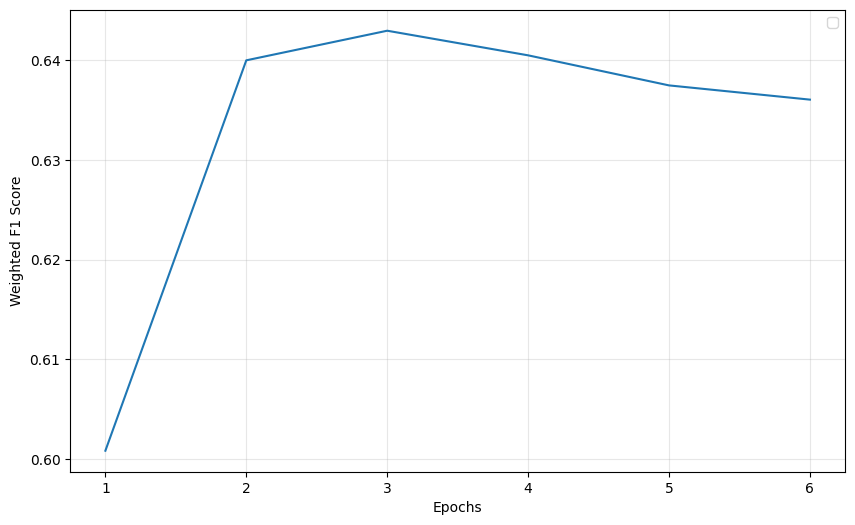

In [26]:
#Training and Validation Loss, Weighted_F1 Curves
import matplotlib.pyplot as plt
import pandas as pd

history = trainer.state.log_history
df = pd.DataFrame(history)

train_df = df[df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]
weighted_f1_df = df[df['eval_f1_weighted'].notna()]

plt.figure(figsize=(10, 6))

plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Training and Validation Loss")
plt.clf()

plt.plot(weighted_f1_df['epoch'], weighted_f1_df['eval_f1_weighted'])
plt.xlabel('Epochs')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Weighted F1 Score")


In [27]:
model_new = AutoModelForSequenceClassification.from_pretrained("distilbert_finetuned-goemotions-final")
tokenizer_new = AutoTokenizer.from_pretrained("distilbert_finetuned-goemotions-final")

model_new.to(device)
model_new.eval()

Loading weights: 100%|██████| 104/104 [00:00<00:00, 10226.89it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [42]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [47]:
def test():
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits
            probs = torch.sigmoid(logits)
            
            all_outputs.extend(probs.cpu().numpy().tolist())
    return all_outputs

In [48]:
texts_path = './Georgian Texts/Vazha Pshavela/'
sources = ['en/', 'ggl/', 'gem/', 'gem_ru/', 'gpt/', 'gpt_ru/']
poems_path = texts_path + 'Poems/revised/'
poem_names = []

ge_poems_directory = os.fsencode(poems_path + 'ge/')
for file in sorted(os.listdir(ge_poems_directory)):
    file = file.decode()
    if file.endswith(".md"):
        poem_names.append(file)

print(poem_names)

['01_i_believe_i_always_have_believed.md', '02_bakur.md', '03_some_day_it_will_happen_i_shall_die.md', '04_i_feel_like_singing_and_i_shall_sing.md', '05_voice_from_the_grave.md', '06_that_in_truth_is_not_manliness.md', '07_the_law_of_the_world_is_thus.md', '08_amiran.md', '09_the_old_song_of_cavaliers.md', '10_consciences_song.md', '11_as_once_you_did_o_lady_as_once_you_did.md', '12_loneliness.md', '13_what_created_me_a_human_being.md', '14_yet_again_shall_i_see_the_spring.md', '15_thrush_its_the_same_song_you_sing.md']


In [49]:
lengths = [len(x) for x in go_emotions['train']['text']]
print(max(lengths))

MAX_LEN = 700

703


In [50]:
from torch.utils.data import DataLoader
MAX_LEN = 64
for source in sources:
    for poem in poem_names:
        poem_text = [line.strip() for line in open(poems_path + source + poem, "r")]
        poem_df = pd.DataFrame(poem_text, columns=['text'])

        test_dataset = CustomDataset(poem_df, tokenizer, MAX_LEN)
        test_params = {'batch_size': 1, 'shuffle': False}
        test_loader = DataLoader(test_dataset, **test_params)
        
        test_outputs = np.array(test())

        test_outputs = (test_outputs >= 0.5).astype(int)
        for label in ekman_classes:
            poem_df[label] = 0

        for i in range(len(test_outputs)):
            for j, label in enumerate(ekman_classes):
                poem_df.at[i, label] = test_outputs[i][j]

        poem_df.to_csv('Code_old/results/poems/sentiment/' + source + poem)

In [51]:
def all_chapter_dataframe(source, ekman_classes):
    total_counts = {label: 0 for label in ekman_classes}
    
    for poem in poem_names:
        df = pd.read_csv('Code_old/results/poems/sentiment/' + source + poem)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        # sum counts directly (since labels are 0/1)  
        for label in ekman_classes:
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

  Sentiment  Count  Count  Count  Count  Count  Count
0     anger     10     17     13     12     15     12
1   disgust      0      1      0      0      0      0
2      fear      0      6      4      5      5      5
3       joy     35     28     27     33     30     34
4   sadness     12     11     10     11      6     10
5  surprise      6     10     13     13      9     13
6   neutral    153    148    151    138    148    140
  Sentiment  Hewitt  Google  Gemini  Gemini_ru  ChatGPT  ChatGPT_ru
0     anger      10      17      13         12       15          12
1   disgust       0       1       0          0        0           0
2      fear       0       6       4          5        5           5
3       joy      35      28      27         33       30          34
4   sadness      12      11      10         11        6          10
5  surprise       6      10      13         13        9          13
6   neutral     153     148     151        138      148         140
0     Models anger disgu

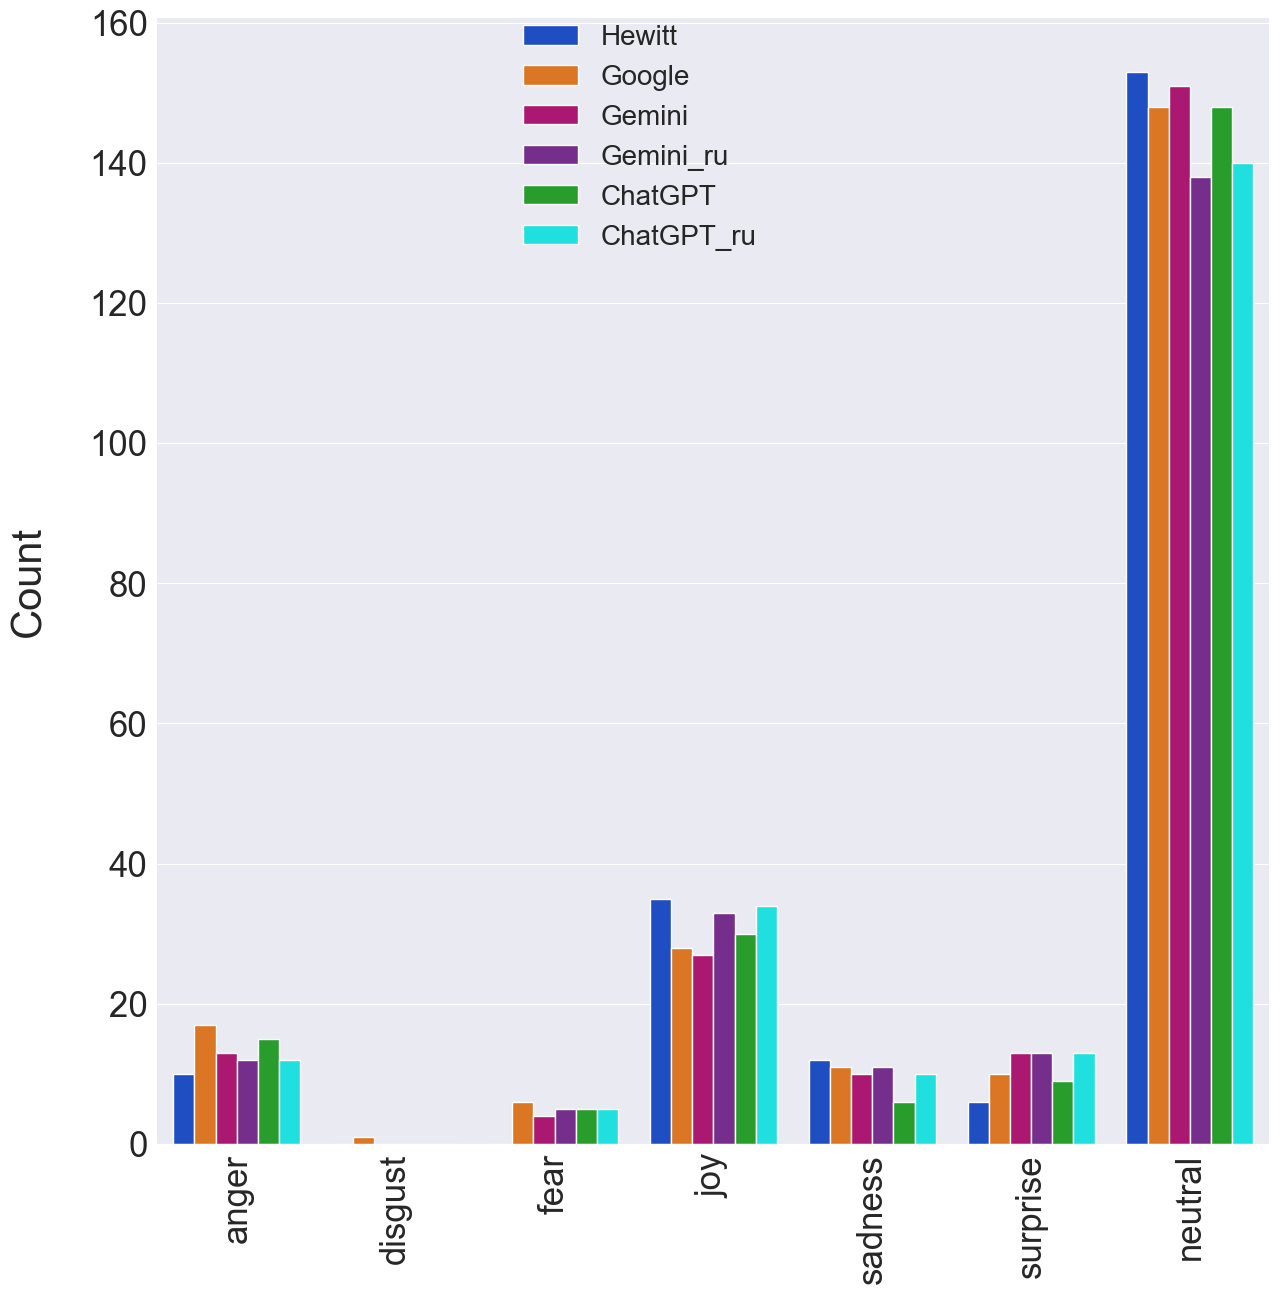

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

hewitt_sentiment = all_chapter_dataframe('en/', ekman_classes)
google_sentiment = all_chapter_dataframe('ggl/', ekman_classes)
gemini_sentiment = all_chapter_dataframe('gem/', ekman_classes)
gemini_ru_sentiment = all_chapter_dataframe('gem_ru/', ekman_classes)
chatgpt_sentiment = all_chapter_dataframe('gpt/', ekman_classes)
chatgpt_ru_sentiment = all_chapter_dataframe('gpt_ru/', ekman_classes)

df_new = pd.concat(
    [
        hewitt_sentiment, 
        google_sentiment['Count'], 
        gemini_sentiment['Count'], 
        gemini_ru_sentiment['Count'], 
        chatgpt_sentiment['Count'],
        chatgpt_ru_sentiment['Count']
    ],
    axis=1
)

print(df_new)

df_new.columns = ['Sentiment', 'Hewitt', 'Google', 'Gemini', 'Gemini_ru', 'ChatGPT', 'ChatGPT_ru']
print(df_new)

df_sentiment_counts = df_new.T.reset_index()
df_sentiment_counts.columns = df_sentiment_counts.iloc[0, ]
df_sentiment_counts = df_sentiment_counts.iloc[1:, ].reset_index(drop=True)
df_sentiment_counts = df_sentiment_counts.rename(columns={'Sentiment': 'Models'})

print(df_sentiment_counts.head())
print(df_sentiment_counts.columns)

df_new = pd.melt(df_new, id_vars="Sentiment", var_name="Models", value_name="Count")
print(df_new)
colors = ["blue", "orange", "magenta", "purple", "green", "cyan"]  
myPalette = sns.xkcd_palette(colors)

sns.set_style("darkgrid")
g = sns.catplot(x='Sentiment', y='Count', hue='Models', data=df_new, kind='bar', height=12, palette=myPalette, legend=True)
g.despine(left=True)
sns.move_legend(g, 'upper center', prop={"size": 20}, title='')
plt.ylabel('Count', labelpad=30, fontsize=30)
plt.xlabel(' ')
#plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) #{tick values, add commas for thousands operator, round to 0 decimal places}
plt.yticks(fontsize= 25)
plt.xticks(fontsize = 25)
plt.xticks(rotation=90)
plt.savefig('Code_old/results/poems/graphs/sentiment_all_ru.png')

In [53]:
sentiment_polarity = {
    'anger': -2,
    'disgust': -1,
    'fear': -2,
    'joy':  2,
    'sadness': -1,
    'surprise': 1,
    'neutral': 0,
}

In [54]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [55]:
def plot_polarity_vs_verse(poem, model_paths, model_labels, sentiment_polarity, output_path):
    plt.figure(figsize = (14, 6))

    for path, label in zip(model_paths, model_labels):
        df = pd.read_csv(path + poem)
        polarity_scores = []
        for _, row in df.iterrows():
            polarity = sum(
                row.get(emotion, 0) * weight for emotion, weight in sentiment_polarity.items()
            )
            polarity_scores.append(polarity)
            
        verses = np.arange(1, len(polarity_scores) + 1)
        
        plt.plot(verses, polarity_scores, label = label)

    plt.ylabel('Sentiment Polarity')#, labelpad=40, fontsize=30)
    plt.xlabel('Verse Number')#, labelpad=30, fontsize=30)
    plt.title(f'Polarity vs. Verse for {poem[:2]}')
    
    plt.legend(title = 'Models')
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()
    plt.savefig(output_path)


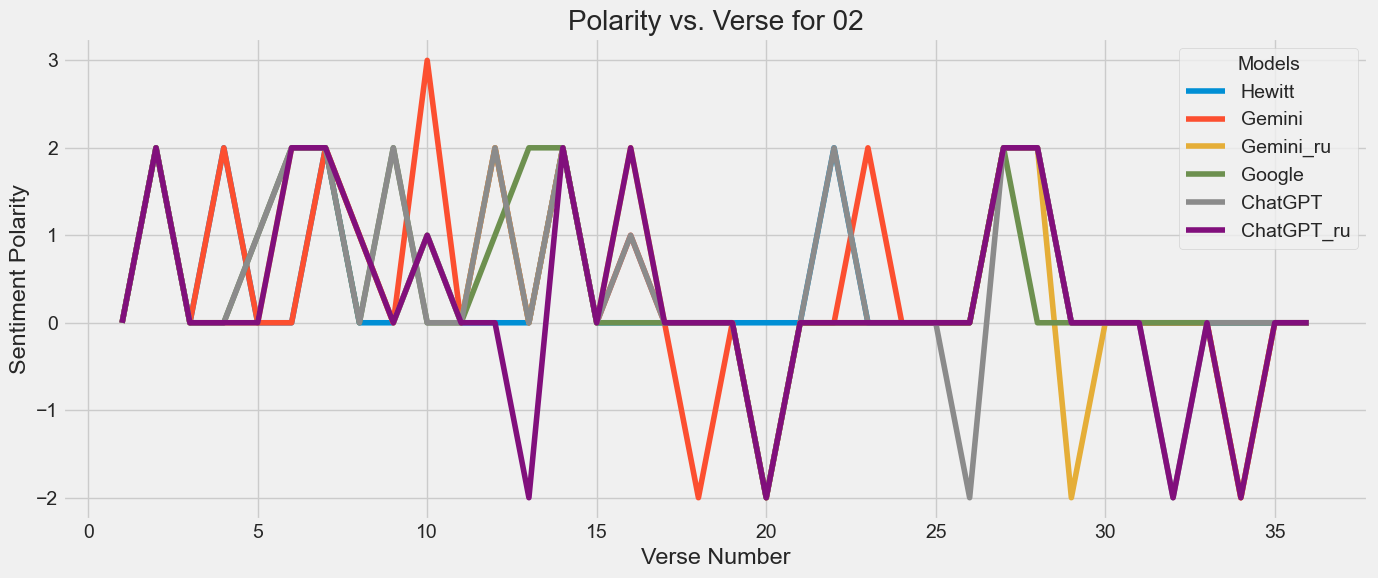

<Figure size 640x480 with 0 Axes>

In [56]:
poem = '02_bakur.md'

model_paths = [
    'Code_old/results/poems/sentiment/en/',
    'Code_old/results/poems/sentiment/gem/',
    'Code_old/results/poems/sentiment/gem_ru/',
    'Code_old/results/poems/sentiment/ggl/',
    'Code_old/results/poems/sentiment/gpt/',
    'Code_old/results/poems/sentiment/gpt_ru/'
]

model_labels = ['Hewitt', 'Gemini', 'Gemini_ru', 'Google', 'ChatGPT', 'ChatGPT_ru']
#plt.savefig('results/poems/graphs/hewitt_polarity.png')
plot_polarity_vs_verse(
    poem, model_paths, model_labels, sentiment_polarity, output_path = f'Code_old/results/poems/graphs/sentiment/{model_labels}_polarity.png'
)

In [57]:
topic_df = pd.read_csv('Code_old/results/poems/sentiment/' + 'gem/' + poem_names[0])
topic_df = topic_df.drop(['Unnamed: 0'], axis=1)

print(topic_df)

for poem in poem_names[1:]:
    df = pd.read_csv('Code_old/results/poems/sentiment/' + 'gem/' + poem)
    df = df.drop(['Unnamed: 0'], axis=1)
    topic_df = pd.concat([topic_df, df], axis=0)

print(topic_df)


                                                text  anger  disgust  fear  \
0  I believe, I've always believed In the eternal...      0        0     0   
1  I believe, even when the ashes Of a good heart...      0        0     0   
2  To suppress evil, to protect the good, It will...      0        0     1   
3  Nature does not kill a good heart, It carries ...      0        0     0   

   joy  sadness  surprise  neutral  
0    0        1         0        0  
1    0        0         0        0  
2    0        0         0        0  
3    0        0         0        0  
                                                 text  anger  disgust  fear  \
0   I believe, I've always believed In the eternal...      0        0     0   
1   I believe, even when the ashes Of a good heart...      0        0     0   
2   To suppress evil, to protect the good, It will...      0        0     1   
3   Nature does not kill a good heart, It carries ...      0        0     0   
0         – Tell us, Elizbara

In [58]:
import re
import gensim 
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
newStopWords = []
stop_words.extend(newStopWords)


def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(text)) if word not in stop_words] for text in texts]
    #list without stopwords

def tokenize(texts):
    for text in texts:
        yield(gensim.utils.simple_preprocess(str(text), deacc=True))
        #tokenized, without punctuation, accents

def preprocessing(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()                                                      # Convert to lowercase
    df['text'] = df['text'].str.replace(r'[^a-zA-Z#]', ' ', regex=True) #     # keep letters and spaces only
    df['text'] = df['text'].apply(lambda x:' '.join([w for w in x.split() if len(w)>2]))     # Remove short words
    df['tokens'] = list(tokenize(df['text']))
    df['tokens_no_stop'] = remove_stopwords(df['text'])
    df['tokens_no_stop_joined'] = df['tokens_no_stop'].apply(lambda x: ' '.join(x) )
    
    return df

def retrieve_text(df):
    doc = '. '.join(df['tokens_no_stop_joined'])
    return doc

def ngrams_series_func(data, n):
    wordList = re.sub("[^\w]", " ",  data).split() #replace non-words with spaces
    ngrams_series = (pd.Series(nltk.ngrams(wordList, n)).value_counts())[:5] #top 5 most frequent
    return ngrams_series

In [59]:
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth": 1}

In [60]:
topic_df = preprocessing(topic_df)
topic_df.head()

,text,anger,disgust,fear,joy,sadness,surprise,neutral,tokens,tokens_no_stop,tokens_no_stop_joined
0,believe always believed the eternal life the s...,0,0,0,0,1,0,0,"[believe, always, believed, the, eternal, life...","[believe, always, believed, eternal, life, sou...",believe always believed eternal life soul good...
1,believe even when the ashes good heart are sca...,0,0,0,0,0,0,0,"[believe, even, when, the, ashes, good, heart,...","[believe, even, ashes, good, heart, scattered,...",believe even ashes good heart scattered wind w...
2,suppress evil protect the good will always gua...,0,0,1,0,0,0,0,"[suppress, evil, protect, the, good, will, alw...","[suppress, evil, protect, good, always, guardi...",suppress evil protect good always guardian poo...
3,nature does not kill good heart carries along ...,0,0,0,0,0,0,0,"[nature, does, not, kill, good, heart, carries...","[nature, kill, good, heart, carries, along, ti...",nature kill good heart carries along time imme...
0,tell elizbara what happened dawn,0,0,0,0,0,0,1,"[tell, elizbara, what, happened, dawn]","[tell, elizbara, happened, dawn]",tell elizbara happened dawn


In [61]:
text = retrieve_text(topic_df)
text.split('. ')

['believe always believed eternal life soul good lover country one pained country fate',
 'believe even ashes good heart scattered wind within one spark still ignites burning desire warmth',
 'suppress evil protect good always guardian poor troubled helper savior rescuer',
 'nature kill good heart carries along time immemorial',
 'tell elizbara happened dawn',
 'leks fall bakuri castle courtyard',
 'want stir old sorrows heart',
 'say men lament bakuri fate',
 'lives loved ones extinguished forever',
 'say man blame',
 'truth speak lie instead',
 'bear burden die soul clung life',
 'seen eyes bakuri battle fall',
 'heart aches alive fall enemy hands',
 'thoughts rise like poison throat',
 'want raise head straighten back',
 'run death take',
 'ashamed shameful',
 'know heard news afar',
 'one blamed thank god one spoke ill',
 'tell story battle',
 'great enemy army came surrounded like fence',
 'seven days fought guns killed many',
 'women making bullets deserve praise indeed',
 'eight

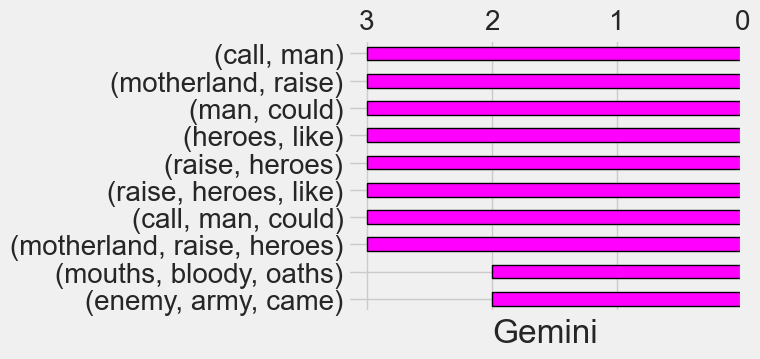

In [62]:
from matplotlib.ticker import MaxNLocator
bigram1 = ngrams_series_func(text, 2)
trigram1 = ngrams_series_func(text, 3)
ngram1 = pd.concat([bigram1, trigram1])

plt.rcParams.update({'font.size': 20})
fig, ax=plt.subplots(1,1, figsize=(8,4))

barh_ax = ax

ngram1[::-1].plot.barh(ax=barh_ax, color='magenta', **barstyle)
barh_ax.yaxis.set_label_position("left")
barh_ax.xaxis.tick_top()
barh_ax.xaxis.set_label_position("bottom")
barh_ax.set_xlim(barh_ax.get_xlim()[::-1])
barh_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
barh_ax.set_xlabel('Gemini')
barh_ax.set_ylabel('', fontsize=50)
plt.tight_layout()
plt.savefig('Code_old/results/poems/graphs/ngrams/gemini.png', facecolor='white')